# 02. Train LSTM Traffic Predictor

In this notebook, we implement, train, and evaluate a PyTorch LSTM model to predict future traffic demand ($Traffic_{t+1}$) based on historical traffic observations. We then precompute these predictions and update the dataset.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import config
import time

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

C:\Users\saran\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Data Preparation

We load `dataset.csv` and construct the sliding window dataset. We shift the traffic column to create the target variable for predicting $Traffic_{t+1}$.

In [2]:
df = pd.read_csv('dataset.csv')

# Create target column Traffic_next by shifting Traffic by -1 within each PatientID
df['Traffic_next'] = df.groupby('PatientID')['Traffic'].shift(-1)

# Drop the last time step (Time == 99) for each patient since we don't have Traffic_next for them
df_lstm = df.dropna(subset=['Traffic_next']).copy()

print(f"LSTM dataset shape: {df_lstm.shape}")

LSTM dataset shape: (990000, 26)


## 2. Train/Test Split

We apply the time-based split: train on earlier time steps (Time <= 78), test/validate on the later time steps (Time >= 79 to predict Time >= 80). We only train on training patients (PatientID <= 8000).

In [3]:
train_df = df_lstm[(df_lstm['PatientID'] <= config.TRAIN_PATIENT_LIMIT) & (df_lstm['Time'] <= 78)]
test_df = df_lstm[(df_lstm['PatientID'] <= config.TRAIN_PATIENT_LIMIT) & (df_lstm['Time'] >= 79)]

print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

# Feature columns: [Traffic_t-3, Traffic_t-2, Traffic_t-1, Traffic]
features = ['Traffic_t-3', 'Traffic_t-2', 'Traffic_t-1', 'Traffic']
target = 'Traffic_next'

X_train = train_df[features].values.astype(np.float32)
y_train = train_df[target].values.astype(np.float32).reshape(-1, 1)

X_test = test_df[features].values.astype(np.float32)
y_test = test_df[target].values.astype(np.float32).reshape(-1, 1)

# Reshape inputs for LSTM: (batch_size, seq_len, input_size)
X_train_lstm = X_train.reshape(-1, 4, 1)
X_test_lstm = X_test.reshape(-1, 4, 1)

print("X_train shape for LSTM:", X_train_lstm.shape)
print("X_test shape for LSTM:", X_test_lstm.shape)

Train samples: 632000
Test samples: 160000
X_train shape for LSTM: (632000, 4, 1)
X_test shape for LSTM: (160000, 4, 1)


## 3. LSTM Model Definition

We implement the LSTM model in PyTorch.

In [4]:
class TrafficLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1):
        super(TrafficLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        # Take the output of the last time step
        out = self.fc(out[:, -1, :])
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TrafficLSTM(input_size=1, hidden_size=32, num_layers=2, output_size=1).to(device)
print(model)

TrafficLSTM(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


## 4. LSTM Training Loop

In [5]:
train_dataset = TensorDataset(torch.tensor(X_train_lstm), torch.tensor(y_train))
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 3
start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_X.size(0)
        
    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{epochs} - Train MSE: {avg_loss:.4f}")

print(f"Training finished in {time.time() - start_time:.2f} seconds.")

Epoch 1/3 - Train MSE: 924.8963


Epoch 2/3 - Train MSE: 97.7761


Epoch 3/3 - Train MSE: 37.1141
Training finished in 21.72 seconds.


## 5. Model Evaluation

We evaluate the model on the test time steps using MAE, RMSE, and MAPE.

In [6]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_lstm).to(device)
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.cpu().numpy()

# Metrics
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Evaluation on Test Time Steps (Time 80-99):")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

Evaluation on Test Time Steps (Time 80-99):
Mean Absolute Error (MAE): 5.0845
Root Mean Squared Error (RMSE): 9.3245
Mean Absolute Percentage Error (MAPE): 8.8452%


## 6. Plot Predictions for Sample Patients

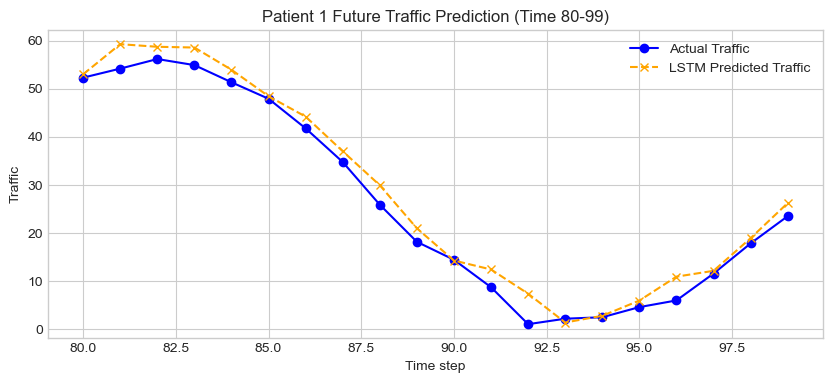

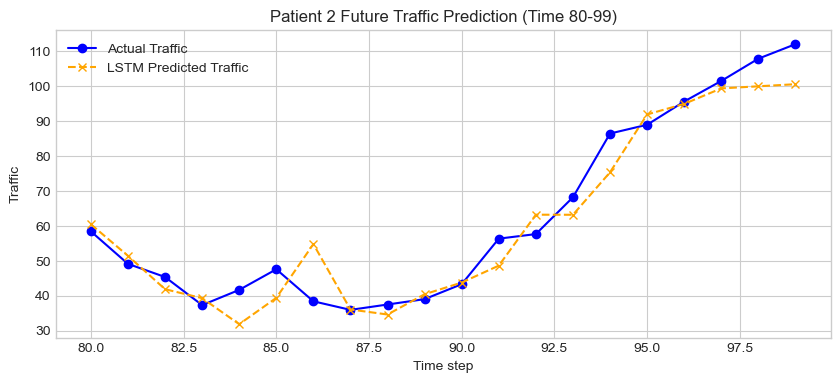

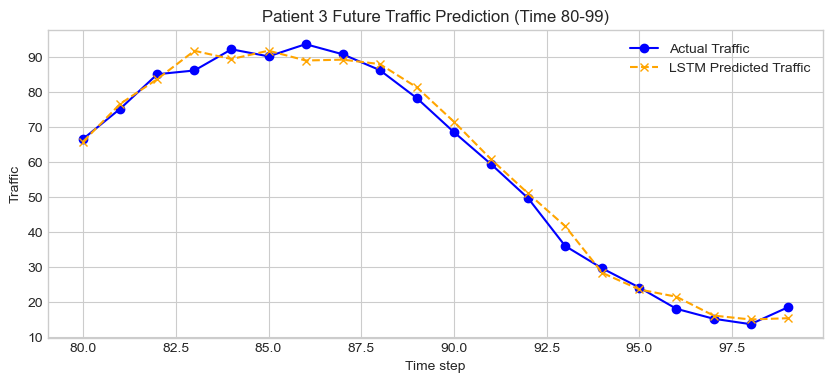

In [7]:
sample_patients = [1, 2, 3]
for pid in sample_patients:
    patient_test = test_df[test_df['PatientID'] == pid].sort_values('Time')
    X_sample = patient_test[features].values.astype(np.float32).reshape(-1, 4, 1)
    y_sample_actual = patient_test[target].values
    times = patient_test['Time'].values + 1 # Target time step is t+1
    
    with torch.no_grad():
        y_sample_pred = model(torch.tensor(X_sample).to(device)).cpu().numpy().flatten()
        
    plt.figure(figsize=(10, 4))
    plt.plot(times, y_sample_actual, label='Actual Traffic', marker='o', color='blue')
    plt.plot(times, y_sample_pred, label='LSTM Predicted Traffic', marker='x', linestyle='--', color='orange')
    plt.title(f"Patient {pid} Future Traffic Prediction (Time 80-99)")
    plt.xlabel("Time step")
    plt.ylabel("Traffic")
    plt.legend()
    plt.show()

## 7. Save Model Weights

In [8]:
torch.save(model.state_dict(), 'lstm_traffic_predictor.pth')
print("Saved LSTM model to lstm_traffic_predictor.pth")

Saved LSTM model to lstm_traffic_predictor.pth


## 8. Precompute Predicted Traffic for DDPG

We run the LSTM model over the entire dataset to compute `Predicted_Traffic` for all rows. For the very first step of each patient (Time == 0), since we don't have enough history, we can set `Predicted_Traffic` to the actual traffic (or we can use the sequence `[Traffic_t-3, Traffic_t-2, Traffic_t-1, Traffic]` at Time 0 which is already filled in the dataset with initial values!). Let's use the features at each row to predict `Traffic_next`, which corresponds to `Predicted_Traffic` at $t+1$.

In [9]:
# Feed forward all features from df to predict Predicted_Traffic
all_X = df[features].values.astype(np.float32).reshape(-1, 4, 1)
model.eval()
with torch.no_grad():
    all_pred = model(torch.tensor(all_X).to(device)).cpu().numpy().flatten()

# Create Predicted_Traffic column by shifting predictions by 1 step per patient
# So that row at Time t has the prediction for Time t (which was made at Time t-1)
df['pred_temp'] = all_pred
df['Predicted_Traffic'] = df.groupby('PatientID')['pred_temp'].shift(1)

# For Time == 0, we don't have a prediction from t-1. We set it to the actual Traffic.
df['Predicted_Traffic'] = df['Predicted_Traffic'].fillna(df['Traffic'])
df.drop(columns=['pred_temp'], inplace=True)

# Save the updated dataset
df.to_csv('dataset.csv', index=False)
print("Updated dataset.csv with Predicted_Traffic column!")
df[['Time', 'PatientID', 'Traffic', 'Predicted_Traffic']].head(10)

Updated dataset.csv with Predicted_Traffic column!


,Time,PatientID,Traffic,Predicted_Traffic
0,0,1,15.728,15.728000
1,1,1,18.906,19.938276
2,2,1,25.608,25.169743
3,3,1,31.359,33.464619
4,4,1,39.467,39.363983
5,5,1,48.705,48.045490
6,6,1,52.997,58.045006
7,7,1,57.266,59.797382
8,8,1,60.771,62.404537
9,9,1,64.703,63.756012
